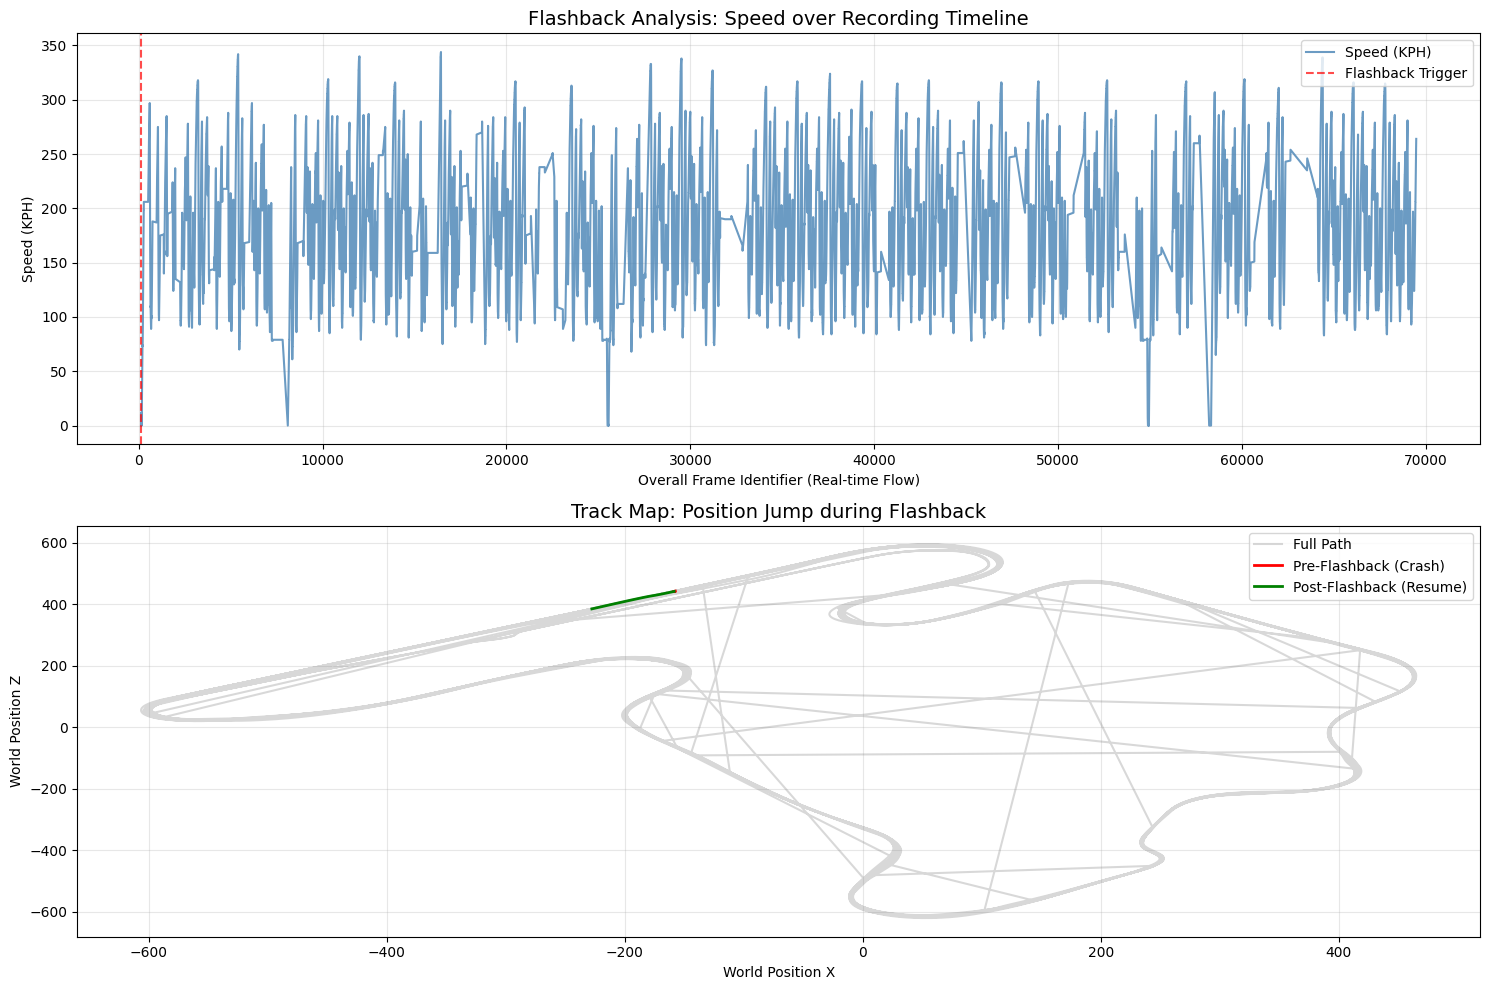

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

def load_f1_jsonl(filename):
    """JSONL 파일을 읽어 리스트로 변환"""
    data = []
    if not os.path.exists(filename):
        print(f"⚠️ 파일을 찾을 수 없습니다: {filename}")
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def visualize_flashback():
    # 1. 데이터 로드
    motion_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_motion.jsonl')
    telemetry_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_telemetry.jsonl')
    event_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_event.jsonl')

    if not motion_data or not telemetry_data:
        return

    # 2. 주행 데이터 추출 (플레이어 차량 기준)
    motion_list = []
    for d in motion_data:
        p_idx = d['m_header']['m_playerCarIndex']
        motion_list.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'frame_id': d['m_header']['m_frameIdentifier'],
            'x': d['m_carMotionData'][p_idx]['m_worldPositionX'],
            'z': d['m_carMotionData'][p_idx]['m_worldPositionZ']
        })
    df_motion = pd.DataFrame(motion_list)

    tele_list = []
    for d in telemetry_data:
        p_idx = d['m_header']['m_playerCarIndex']
        tele_list.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'speed': d['m_carTelemetryData'][p_idx]['m_speed']
        })
    df_tele = pd.DataFrame(tele_list)

    # 3. 되감기 이벤트 추출
    fb_events = []
    if event_data:
        for d in event_data:
            if d.get('event_info', {}).get('event_code') == 'FLBK':
                fb_events.append(d['m_header']['m_overallFrameIdentifier'])

    # 4. 시각화
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # [그래프 1] 속도 변화 및 되감기 시점 (Timeline 분석)
    ax1.plot(df_tele['overall_frame'], df_tele['speed'], label='Speed (KPH)', color='steelblue', alpha=0.8)
    for fb in fb_events:
        ax1.axvline(x=fb, color='red', linestyle='--', alpha=0.7, label='Flashback Trigger')
    
    ax1.set_title('Flashback Analysis: Speed over Recording Timeline', fontsize=14)
    ax1.set_xlabel('Overall Frame Identifier (Real-time Flow)')
    ax1.set_ylabel('Speed (KPH)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # [그래프 2] 트랙 위 위치 변화 (Jump/Overlap 분석)
    # 되감기 시 좌표가 갑자기 튀는 구간을 점으로 표시
    ax2.plot(df_motion['x'], df_motion['z'], color='gray', alpha=0.3, label='Full Path')
    
    # 되감기 발생 시점 전후 50프레임씩 강조해서 표시
    for fb in fb_events:
        # 되감기 직전 (사고 구간)
        crash_segment = df_motion[(df_motion['overall_frame'] > fb - 100) & (df_motion['overall_frame'] <= fb)]
        ax2.plot(crash_segment['x'], crash_segment['z'], color='red', linewidth=2, label='Pre-Flashback (Crash)')
        
        # 되감기 직후 (다시 시작하는 구간)
        resume_segment = df_motion[(df_motion['overall_frame'] > fb) & (df_motion['overall_frame'] <= fb + 100)]
        ax2.plot(resume_segment['x'], resume_segment['z'], color='green', linewidth=2, label='Post-Flashback (Resume)')

    ax2.set_title('Track Map: Position Jump during Flashback', fontsize=14)
    ax2.set_xlabel('World Position X')
    ax2.set_ylabel('World Position Z')
    ax2.grid(True, alpha=0.3)
    # 범례 중복 제거
    handles, labels = ax2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax2.legend(by_label.values(), by_label.keys())

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_flashback()

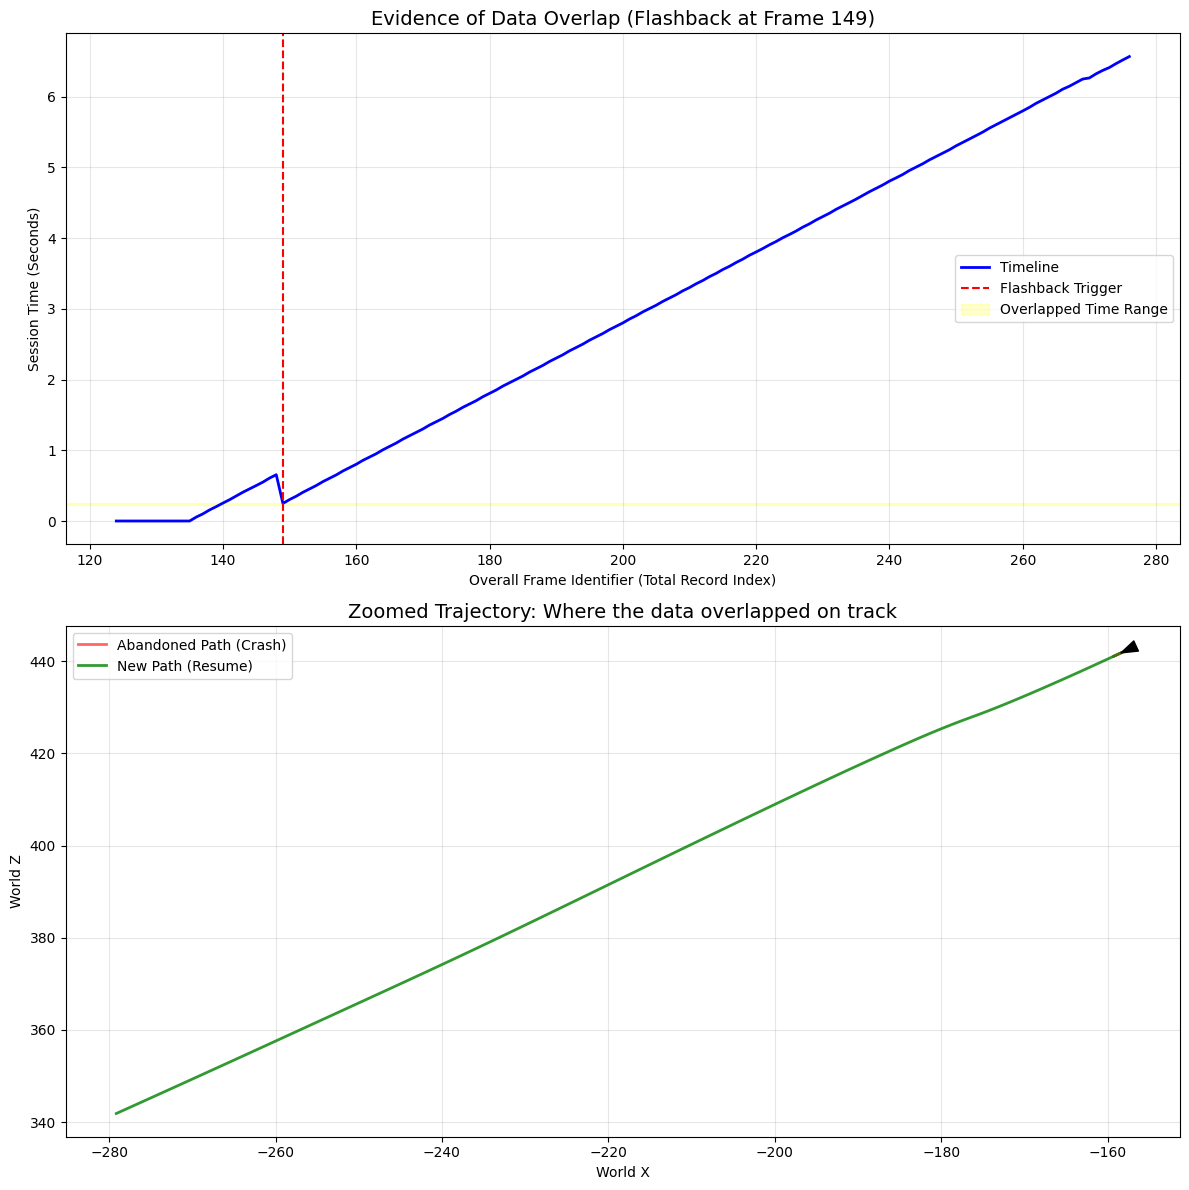

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data(filename):
    data = []
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
        return data
    except FileNotFoundError:
        return None

# 1. 데이터 로드
motion_data = load_data(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_motion.jsonl')
event_data = load_data(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_event.jsonl')

if not motion_data or not event_data:
    print("데이터 파일이 부족합니다. (motion, event 파일 필요)")
else:
    # 2. 플레이어 데이터 추출 (Overall Frame과 Session Time 위주)
    records = []
    for d in motion_data:
        p_idx = d['m_header']['m_playerCarIndex']
        records.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'session_time': d['m_header']['m_sessionTime'],
            'x': d['m_carMotionData'][p_idx]['m_worldPositionX'],
            'z': d['m_carMotionData'][p_idx]['m_worldPositionZ']
        })
    df = pd.DataFrame(records)

    # 3. 첫 번째 되감기(FLBK) 시점 찾기
    flashback_point = None
    for d in event_data:
        if d.get('event_info', {}).get('event_code') == 'FLBK':
            flashback_point = d['m_header']['m_overallFrameIdentifier']
            rewind_to_time = d['event_info']['details']['flashbackSessionTime']
            break

    if flashback_point is None:
        print("기록 중 되감기(Flashback) 이벤트가 발견되지 않았습니다.")
    else:
        # 4. 분석 구간 설정 (되감기 시점 전후 확대)
        # 되감기 발생 시점 근처의 데이터만 필터링
        margin = 300  # 약 5~10초 내외의 프레임 구간
        df_zoom = df[(df['overall_frame'] > flashback_point - margin) & 
                    (df['overall_frame'] < flashback_point + margin)].copy()

        # 시각화
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

        # [그래프 1] 중첩의 증거: Session Time vs Overall Frame
        # 정상 주행 시에는 우상향 직선이지만, 되감기 시 '계단식' 중첩 발생
        ax1.plot(df_zoom['overall_frame'], df_zoom['session_time'], color='blue', linewidth=2, label='Timeline')
        ax1.axvline(x=flashback_point, color='red', linestyle='--', label='Flashback Trigger')
        
        # 중첩 구간 강조 (동일한 Session Time이 발생하는 영역)
        overlap_time_min = rewind_to_time
        overlap_time_max = df[df['overall_frame'] == flashback_point]['session_time'].values[0]
        ax1.axhspan(overlap_time_min, overlap_time_max, color='yellow', alpha=0.2, label='Overlapped Time Range')

        ax1.set_title(f'Evidence of Data Overlap (Flashback at Frame {flashback_point})', fontsize=14)
        ax1.set_xlabel('Overall Frame Identifier (Total Record Index)')
        ax1.set_ylabel('Session Time (Seconds)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # [그래프 2] 물리적 중첩: X, Z 좌표 확대
        # 사고가 났던 경로(빨강)와 새로 달리는 경로(초록) 비교
        pre_fb = df_zoom[df_zoom['overall_frame'] <= flashback_point]
        post_fb = df_zoom[df_zoom['overall_frame'] > flashback_point]

        ax2.plot(pre_fb['x'], pre_fb['z'], color='red', alpha=0.6, linewidth=2, label='Abandoned Path (Crash)')
        ax2.plot(post_fb['x'], post_fb['z'], color='green', alpha=0.8, linewidth=2, label='New Path (Resume)')
        
        # 되감기로 인해 좌표가 튀는 지점에 화살표 표시
        start_jump = pre_fb.iloc[-1]
        end_jump = post_fb.iloc[0]
        ax2.annotate('', xy=(end_jump['x'], end_jump['z']), xytext=(start_jump['x'], start_jump['z']),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

        ax2.set_title('Zoomed Trajectory: Where the data overlapped on track', fontsize=14)
        ax2.set_xlabel('World X')
        ax2.set_ylabel('World Z')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


🔍 [되감기 감지] 전체 프레임 149:
   - 진짜 사고 발생 시간: 0.655초
   - 되감기된 목표 시간: 0.230초
   👉 트랙 위에서 총 0.425초 만큼 과거로 돌아갔습니다.



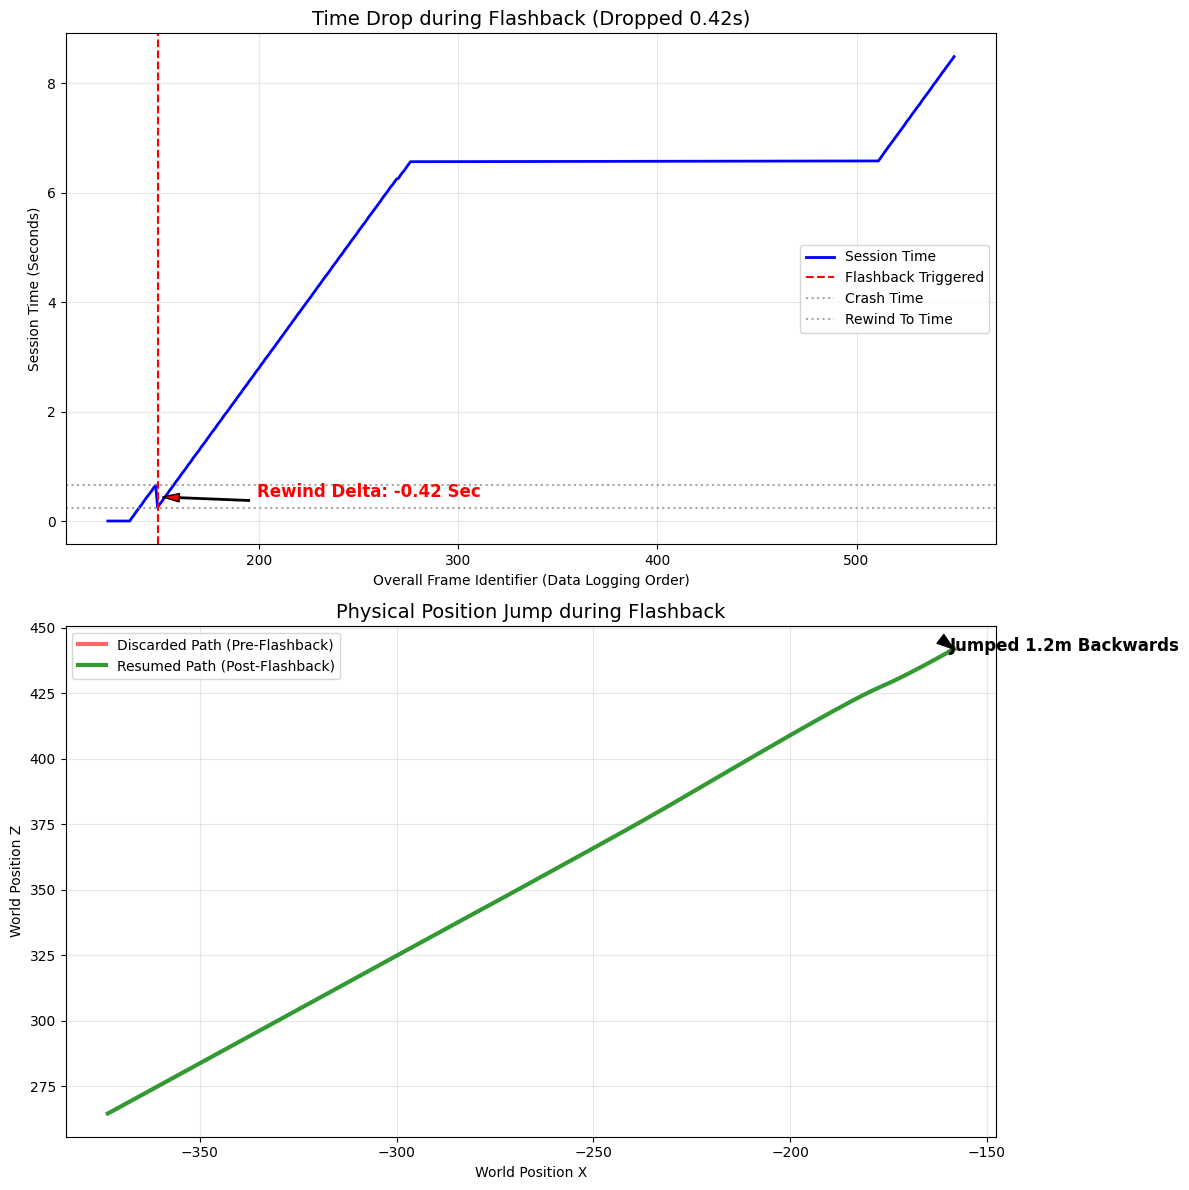

In [8]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import numpy as np

def load_jsonl(filename):
    if not os.path.exists(filename):
        print(f"⚠️ {filename} 파일이 존재하지 않습니다.")
        return []
    with open(filename, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def analyze_and_visualize_flashback(motion_file, event_file):
    # 1. 데이터 로드
    motion_data = load_jsonl(motion_file)
    event_data = load_jsonl(event_file)

    if not motion_data or not event_data:
        return

    # 2. Motion 데이터프레임 생성 (위치 및 시간 정보)
    records = []
    for d in motion_data:
        header = d['m_header']
        p_idx = header['m_playerCarIndex']
        car_data = d['m_carMotionData'][p_idx]
        
        records.append({
            'overall_frame': header['m_overallFrameIdentifier'],
            'session_time': header['m_sessionTime'],
            'frame_id': header['m_frameIdentifier'],
            'x': car_data['m_worldPositionX'],
            'z': car_data['m_worldPositionZ']
        })
    df = pd.DataFrame(records)

    # 3. 되감기 이벤트(FLBK) 탐색 및 진짜 시간 계산
    flashbacks = []
    for e in event_data:
        if e.get('event_info', {}).get('event_code') == 'FLBK':
            trigger_frame = e['m_header']['m_overallFrameIdentifier']
            rewind_to_time = e['event_info']['details']['flashbackSessionTime']
            
            # [수정됨] 이벤트 프레임 이전에 기록된 데이터 중 가장 큰 session_time 찾기 (실제 사고 시점)
            pre_crash_data = df[df['overall_frame'] < trigger_frame]
            
            if not pre_crash_data.empty:
                crash_time = pre_crash_data['session_time'].max()
                rewind_delta = crash_time - rewind_to_time
                
                flashbacks.append({
                    'trigger_frame': trigger_frame,
                    'crash_time': crash_time,
                    'rewind_to_time': rewind_to_time,
                    'rewind_delta': rewind_delta
                })
                print(f"🔍 [되감기 감지] 전체 프레임 {trigger_frame}:")
                print(f"   - 진짜 사고 발생 시간: {crash_time:.3f}초")
                print(f"   - 되감기된 목표 시간: {rewind_to_time:.3f}초")
                print(f"   👉 트랙 위에서 총 {rewind_delta:.3f}초 만큼 과거로 돌아갔습니다.\n")

    if not flashbacks:
        print("기록 내에 되감기(FLBK) 이벤트가 없습니다.")
        return

    # 4. 시각화 (첫 번째 발생한 되감기 기준)
    fb = flashbacks[0]
    margin = 400  # 그래프에 보여줄 전후 프레임 수 (약 6~7초 분량)
    
    df_zoom = df[(df['overall_frame'] >= fb['trigger_frame'] - margin) & 
                 (df['overall_frame'] <= fb['trigger_frame'] + margin)]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # --- [그래프 1] 시간적 중첩 (Session Time Jump) ---
    ax1.plot(df_zoom['overall_frame'], df_zoom['session_time'], color='blue', linewidth=2, label='Session Time')
    
    ax1.axvline(x=fb['trigger_frame'], color='red', linestyle='--', label='Flashback Triggered')
    ax1.axhline(y=fb['crash_time'], color='gray', linestyle=':', alpha=0.7, label='Crash Time')
    ax1.axhline(y=fb['rewind_to_time'], color='gray', linestyle=':', alpha=0.7, label='Rewind To Time')
    
    # 시간차(Delta) 화살표 및 텍스트
    ax1.annotate(f"Rewind Delta: -{fb['rewind_delta']:.2f} Sec", 
                 xy=(fb['trigger_frame'], (fb['crash_time'] + fb['rewind_to_time'])/2),
                 xytext=(fb['trigger_frame'] + 50, (fb['crash_time'] + fb['rewind_to_time'])/2),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
                 fontsize=12, color='red', fontweight='bold')

    ax1.set_title(f"Time Drop during Flashback (Dropped {fb['rewind_delta']:.2f}s)", fontsize=14)
    ax1.set_xlabel('Overall Frame Identifier (Data Logging Order)')
    ax1.set_ylabel('Session Time (Seconds)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- [그래프 2] 물리적 점프 (X, Z Trajectory) ---
    # 사고 전 궤적과 되감기 후 궤적 분리
    pre_fb = df_zoom[(df_zoom['overall_frame'] < fb['trigger_frame']) & (df_zoom['session_time'] >= fb['rewind_to_time'])]
    post_fb = df_zoom[(df_zoom['overall_frame'] > fb['trigger_frame'])]

    ax2.plot(pre_fb['x'], pre_fb['z'], color='red', alpha=0.6, linewidth=3, label='Discarded Path (Pre-Flashback)')
    ax2.plot(post_fb['x'], post_fb['z'], color='green', alpha=0.8, linewidth=3, label='Resumed Path (Post-Flashback)')
    
    # 두 지점 사이의 공간적 거리 계산
    if not pre_fb.empty and not post_fb.empty:
        # 사고 발생 직전의 가장 마지막 좌표
        crash_point = pre_fb.loc[pre_fb['session_time'].idxmax()]
        # 되감기 이후 새로 시작하는 좌표
        resume_point = post_fb.iloc[0]
        
        distance = np.sqrt((crash_point['x'] - resume_point['x'])**2 + (crash_point['z'] - resume_point['z'])**2)
        
        ax2.annotate(f"Jumped {distance:.1f}m Backwards", 
                     xy=(resume_point['x'], resume_point['z']), 
                     xytext=(crash_point['x'], crash_point['z']),
                     arrowprops=dict(facecolor='black', edgecolor='black', shrink=0.05, width=2, headwidth=8),
                     fontsize=12, fontweight='bold')

    ax2.set_title(f"Physical Position Jump during Flashback", fontsize=14)
    ax2.set_xlabel('World Position X')
    ax2.set_ylabel('World Position Z')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_and_visualize_flashback(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_motion.jsonl', r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_event.jsonl')

MP4 file saved.


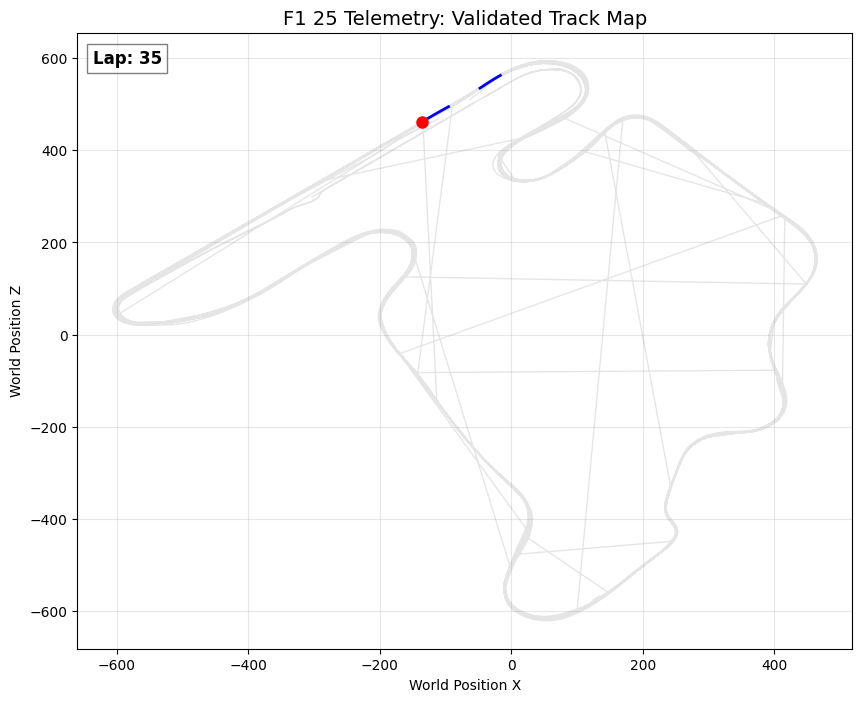

In [19]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import imageio_ffmpeg

plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

def load_f1_jsonl(filename):
    data = []
    if not os.path.exists(filename):
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def save_animation_to_mp4():
    motion_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_motion.jsonl')
    telemetry_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_telemetry.jsonl')
    lap_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_lap.jsonl')
    
    if not motion_data or not telemetry_data or not lap_data:
        return

    motion_list = []
    for d in motion_data:
        p_idx = d['m_header']['m_playerCarIndex']
        motion_list.append({
            'time': d['m_header']['m_sessionTime'],
            'x': d['m_carMotionData'][p_idx]['m_worldPositionX'],
            'z': d['m_carMotionData'][p_idx]['m_worldPositionZ']
        })
    df_motion = pd.DataFrame(motion_list)

    tele_list = []
    for d in telemetry_data:
        p_idx = d['m_header']['m_playerCarIndex']
        tele_list.append({
            'time': d['m_header']['m_sessionTime'],
            'speed': d['m_carTelemetryData'][p_idx]['m_speed']
        })
    df_tele = pd.DataFrame(tele_list)

    lap_list = []
    for d in lap_data:
        p_idx = d['m_header']['m_playerCarIndex']
        lap_list.append({
            'time': d['m_header']['m_sessionTime'],
            'lap_num': d['m_lapData'][p_idx]['m_currentLapNum']
        })
    df_lap = pd.DataFrame(lap_list)

    df_merged = pd.merge_asof(
        df_motion.sort_values('time'), 
        df_tele.sort_values('time'), 
        on='time', 
        direction='nearest'
    )
    
    df_merged = pd.merge_asof(
        df_merged,
        df_lap.sort_values('time'),
        on='time',
        direction='nearest'
    )

    df_merged['dx'] = df_merged['x'].diff()
    df_merged['dz'] = df_merged['z'].diff()
    df_merged['dt'] = df_merged['time'].diff()

    df_merged['dt'] = df_merged['dt'].replace(0, np.nan)

    df_merged['calc_speed_kph'] = (np.sqrt(df_merged['dx']**2 + df_merged['dz']**2) / df_merged['dt']) * 3.6

    speed_tolerance = 50.0

    anomaly_mask = np.abs(df_merged['calc_speed_kph'] - df_merged['speed']) > speed_tolerance
    df_merged.loc[anomaly_mask, ['x', 'z']] = np.nan

    df_filtered = df_merged.iloc[::5].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.plot(df_filtered['x'], df_filtered['z'], color='gray', alpha=0.2, linewidth=1)
    
    car_trail, = ax.plot([], [], color='blue', linewidth=2)
    car_dot, = ax.plot([], [], marker='o', color='red', markersize=8)
    
    lap_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    ax.set_title('F1 25 Telemetry: Validated Track Map', fontsize=14)
    ax.set_xlabel('World Position X')
    ax.set_ylabel('World Position Z')
    ax.grid(True, alpha=0.3)

    x_min, x_max = df_filtered['x'].min(), df_filtered['x'].max()
    z_min, z_max = df_filtered['z'].min(), df_filtered['z'].max()
    margin_x = (x_max - x_min) * 0.05
    margin_z = (z_max - z_min) * 0.05
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(z_min - margin_z, z_max + margin_z)

    trail_length = 10

    def init():
        car_trail.set_data([], [])
        car_dot.set_data([], [])
        lap_text.set_text('')
        return car_trail, car_dot, lap_text

    def update(frame):
        start_idx = max(0, frame - trail_length)
        
        x_trail = df_filtered['x'].iloc[start_idx:frame+1]
        z_trail = df_filtered['z'].iloc[start_idx:frame+1]
        
        car_trail.set_data(x_trail, z_trail)
        car_dot.set_data([df_filtered['x'].iloc[frame]], [df_filtered['z'].iloc[frame]])
        
        current_lap = df_filtered['lap_num'].iloc[frame]
        lap_text.set_text(f'Lap: {int(current_lap)}')
        
        return car_trail, car_dot, lap_text

    ani = animation.FuncAnimation(
        fig, update, frames=len(df_filtered),
        init_func=init, blit=True, interval=20, repeat=False
    )

    writer = animation.FFMpegWriter(fps=30, bitrate=1800)
    ani.save('f1_telemetry_full_validated.mp4', writer=writer)
    print("MP4 file saved.")

if __name__ == "__main__":
    save_animation_to_mp4()

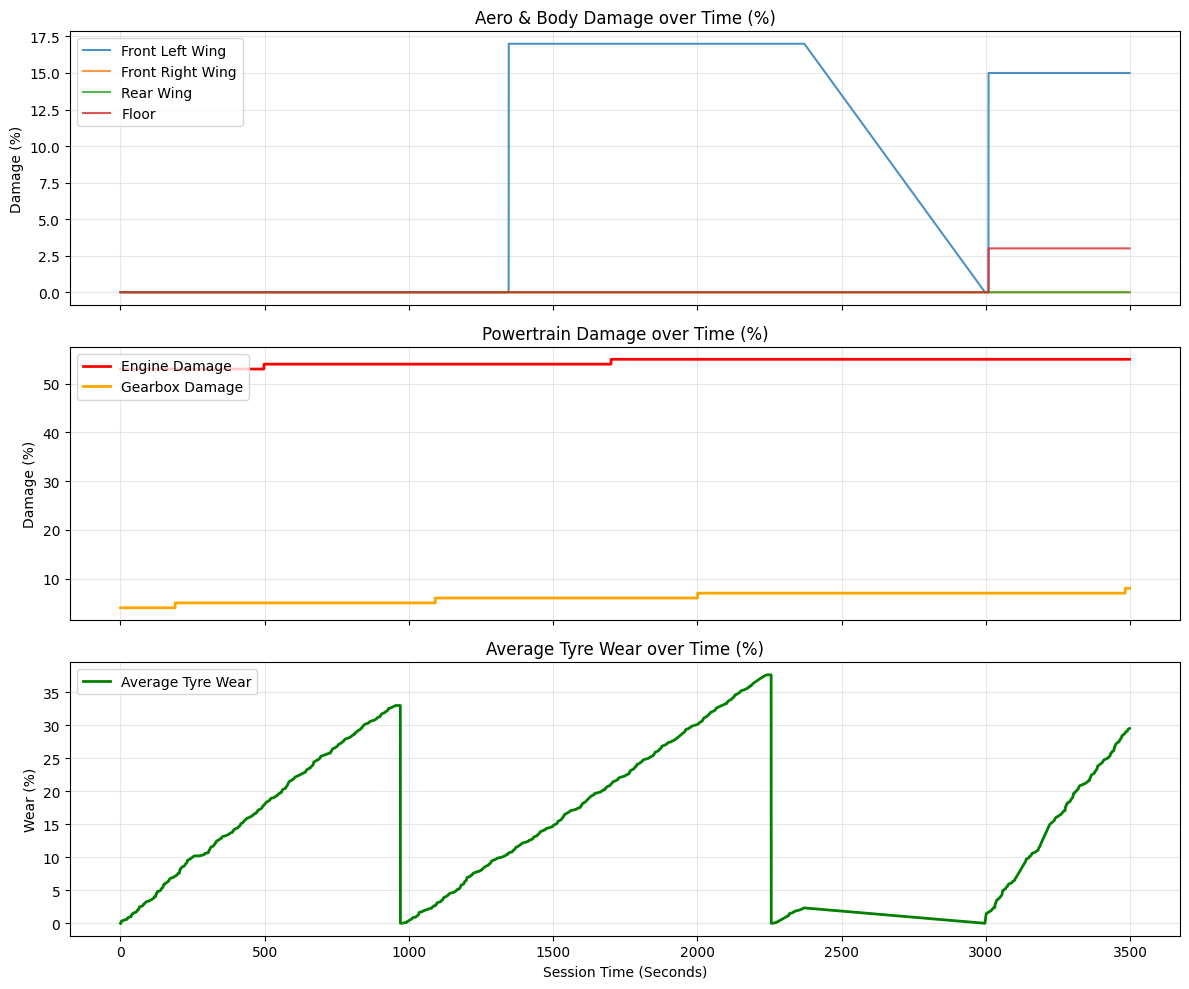

In [20]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

def load_f1_jsonl(filename):
    data = []
    if not os.path.exists(filename):
        print(f"⚠️ 파일을 찾을 수 없습니다: {filename}")
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data

def visualize_car_damage():
    # 경로를 본인의 환경에 맞게 확인해주세요
    damage_data = load_f1_jsonl(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_damage.jsonl')
    
    if not damage_data:
        return

    damage_list = []
    for d in damage_data:
        try:
            p_idx = d['m_header']['m_playerCarIndex']
            car_dmg = d['m_carDamageData'][p_idx]
            
            # 타이어 마모도 평균 (4짝) - 데이터 구조에 따라 배열 길이는 4
            tyres_wear = car_dmg.get('m_tyresWear', [0,0,0,0])
            avg_tyre_wear = sum(tyres_wear) / 4.0
            
            damage_list.append({
                'time': d['m_header']['m_sessionTime'],
                'front_left_wing': car_dmg.get('m_frontLeftWingDamage', 0),
                'front_right_wing': car_dmg.get('m_frontRightWingDamage', 0),
                'rear_wing': car_dmg.get('m_rearWingDamage', 0),
                'floor': car_dmg.get('m_floorDamage', 0),
                'engine': car_dmg.get('m_engineDamage', 0),
                'gearbox': car_dmg.get('m_gearBoxDamage', 0),
                'avg_tyre_wear': avg_tyre_wear
            })
        except (KeyError, IndexError):
            continue
            
    df_damage = pd.DataFrame(damage_list)
    
    # 시간순 정렬 (타임라인 확인을 위해 필수)
    df_damage = df_damage.sort_values('time').reset_index(drop=True)

    # 시각화 (3개의 서브플롯)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # 1. 에어로/차체 데미지 (프론트 윙, 리어 윙, 플로어)
    axes[0].plot(df_damage['time'], df_damage['front_left_wing'], label='Front Left Wing', alpha=0.8)
    axes[0].plot(df_damage['time'], df_damage['front_right_wing'], label='Front Right Wing', alpha=0.8)
    axes[0].plot(df_damage['time'], df_damage['rear_wing'], label='Rear Wing', alpha=0.8)
    axes[0].plot(df_damage['time'], df_damage['floor'], label='Floor', alpha=0.8)
    axes[0].set_title('Aero & Body Damage over Time (%)', fontsize=12)
    axes[0].set_ylabel('Damage (%)')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)

    # 2. 파워트레인 데미지 (엔진, 기어박스)
    axes[1].plot(df_damage['time'], df_damage['engine'], label='Engine Damage', color='red', linewidth=2)
    axes[1].plot(df_damage['time'], df_damage['gearbox'], label='Gearbox Damage', color='orange', linewidth=2)
    axes[1].set_title('Powertrain Damage over Time (%)', fontsize=12)
    axes[1].set_ylabel('Damage (%)')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)

    # 3. 타이어 마모도 (평균)
    axes[2].plot(df_damage['time'], df_damage['avg_tyre_wear'], label='Average Tyre Wear', color='green', linewidth=2)
    axes[2].set_title('Average Tyre Wear over Time (%)', fontsize=12)
    axes[2].set_xlabel('Session Time (Seconds)')
    axes[2].set_ylabel('Wear (%)')
    axes[2].legend(loc='upper left')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_car_damage()

In [21]:
import json
import os

def debug_car_damage():
    filename = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_damage.jsonl'
    
    if not os.path.exists(filename):
        print("파일을 찾을 수 없습니다.")
        return
        
    print("=== [극초반 데이터 확인 (파싱 오프셋 오류 확인용)] ===")
    count = 0
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                p_idx = d['m_header']['m_playerCarIndex']
                car_dmg = d['m_carDamageData'][p_idx]
                
                print(f"Time: {d['m_header']['m_sessionTime']:.2f} | Player Index: {p_idx} | "
                      f"Engine Dmg: {car_dmg.get('m_engineDamage')} | "
                      f"FL Wing Dmg: {car_dmg.get('m_frontLeftWingDamage')}")
                
                count += 1
                if count >= 5: # 처음 5개만 출력
                    break
            except Exception:
                continue

    print("\n=== [윙 데미지가 갑자기 줄어드는 순간 추적] ===")
    prev_wing = 0
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                p_idx = d['m_header']['m_playerCarIndex']
                car_dmg = d['m_carDamageData'][p_idx]
                curr_wing = car_dmg.get('m_frontLeftWingDamage', 0)
                
                # 데미지가 전보다 5 이상 작아지면 (수리된 것처럼 보이면) 출력
                if curr_wing < prev_wing - 5:
                    print(f"⚠️ 윙 데미지 하락 감지! Time: {d['m_header']['m_sessionTime']:.2f} | "
                          f"{prev_wing}% -> {curr_wing}% (Player Index: {p_idx})")
                prev_wing = curr_wing
            except Exception:
                continue

if __name__ == "__main__":
    debug_car_damage()

=== [극초반 데이터 확인 (파싱 오프셋 오류 확인용)] ===
Time: 0.00 | Player Index: 8 | Engine Dmg: 53 | FL Wing Dmg: 0
Time: 0.00 | Player Index: 8 | Engine Dmg: 53 | FL Wing Dmg: 0
Time: 0.00 | Player Index: 8 | Engine Dmg: 53 | FL Wing Dmg: 0
Time: 0.00 | Player Index: 8 | Engine Dmg: 53 | FL Wing Dmg: 0
Time: 0.00 | Player Index: 8 | Engine Dmg: 53 | FL Wing Dmg: 0

=== [윙 데미지가 갑자기 줄어드는 순간 추적] ===
⚠️ 윙 데미지 하락 감지! Time: 2996.62 | 17% -> 0% (Player Index: 8)


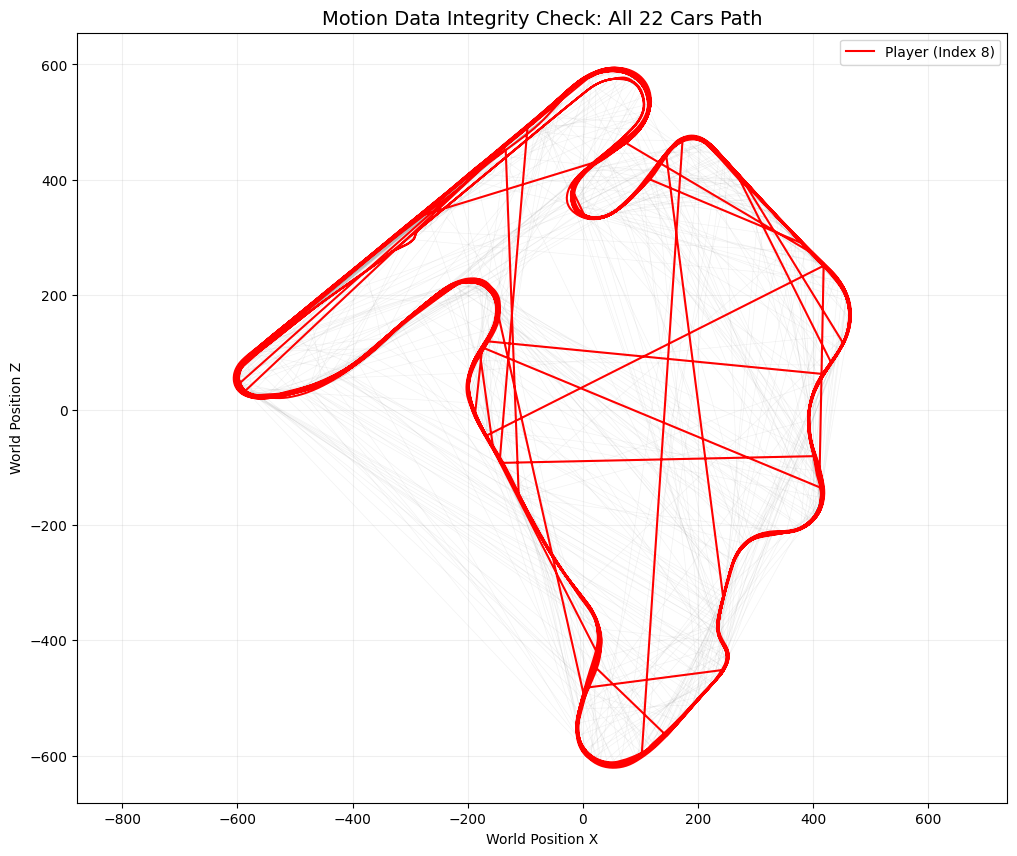

In [ ]:
#record_motion.jsonl 시각화
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

def load_motion_only(filename):
    data = []
    if not os.path.exists(filename):
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def analyze_motion_integrity():
    # 1. 파일 로드
    filename = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_motion.jsonl'
    motion_data = load_motion_only(filename)
    
    if not motion_data:
        print("파일을 찾을 수 없습니다.")
        return

    # 2. 데이터 구조화 (모든 차량의 궤적 저장)
    # 22대 차량 각각의 X, Z 좌표를 리스트로 관리
    trajectories = {i: {'x': [], 'z': []} for i in range(22)}
    
    for frame in motion_data:
        for i in range(22):
            try:
                car = frame['m_carMotionData'][i]
                trajectories[i]['x'].append(car['m_worldPositionX'])
                trajectories[i]['z'].append(car['m_worldPositionZ'])
            except (KeyError, IndexError):
                continue

    # 3. 시각화
    plt.figure(figsize=(12, 10))
    
    # AI 차량 궤적 (옅은 회색으로 전체 흐름 확인)
    for i in range(22):
        plt.plot(trajectories[i]['x'], trajectories[i]['z'], color='gray', alpha=0.1, linewidth=0.5)
    
    # 플레이어 차량 궤적 강조 (마지막 프레임 헤더 기준)
    p_idx = motion_data[-1]['m_header']['m_playerCarIndex']
    plt.plot(trajectories[p_idx]['x'], trajectories[p_idx]['z'], color='red', linewidth=1.5, label=f'Player (Index {p_idx})')

    plt.title('Motion Data Integrity Check: All 22 Cars Path', fontsize=14)
    plt.xlabel('World Position X')
    plt.ylabel('World Position Z')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.axis('equal') # 비율 유지 필수
    plt.show()

if __name__ == "__main__":
    analyze_motion_integrity()

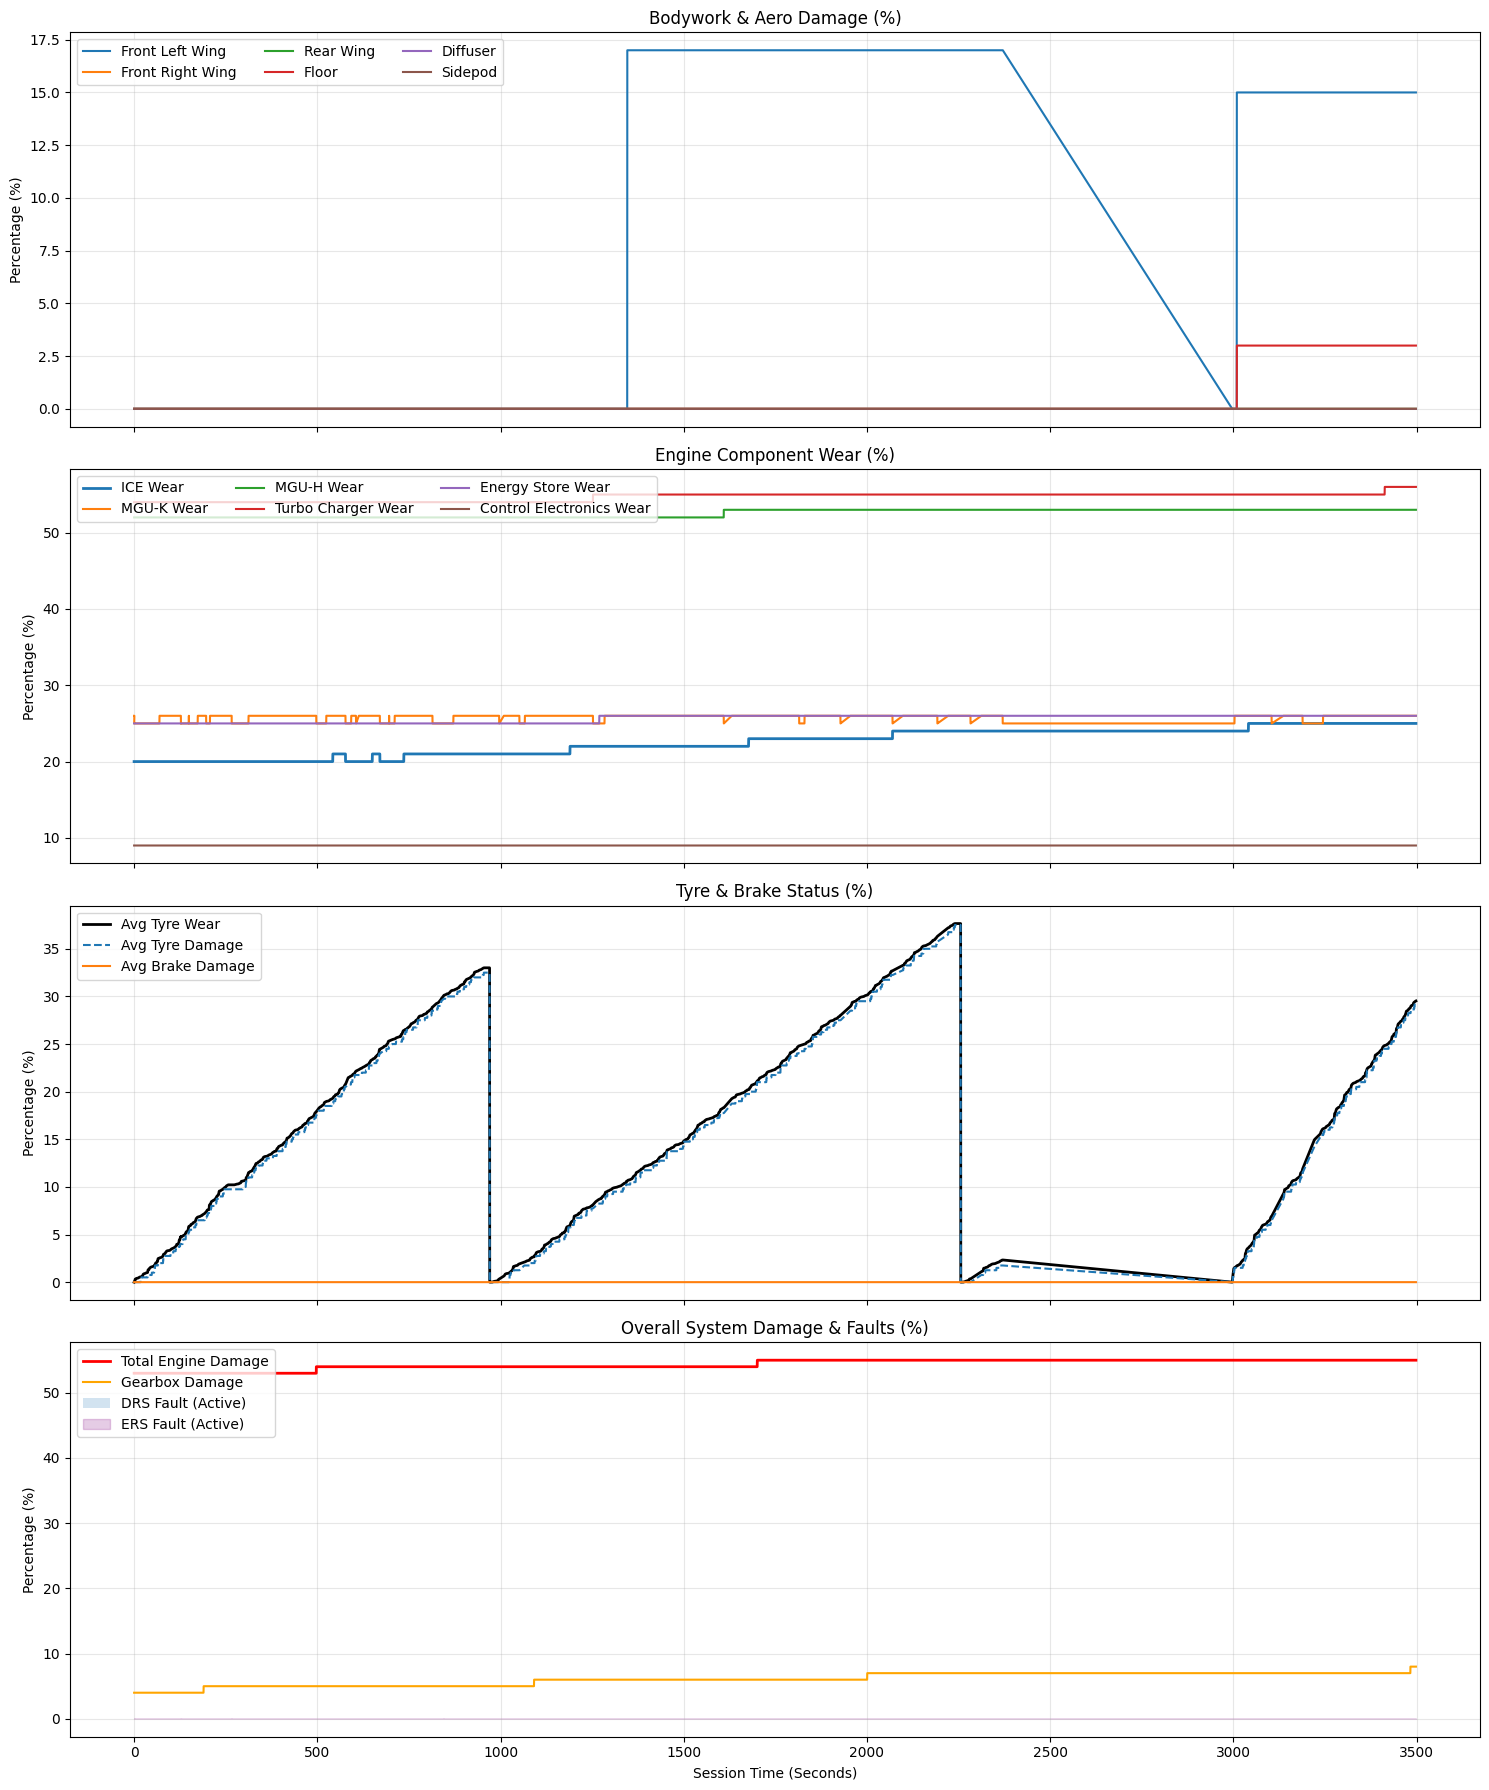

In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

def load_f1_jsonl(filename):
    data = []
    if not os.path.exists(filename):
        print(f"파일을 찾을 수 없습니다: {filename}")
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data

def visualize_player_damage_complete():
    # 파일 경로 설정
    filename = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\record_damage.jsonl'
    raw_data = load_f1_jsonl(filename)
    
    if not raw_data:
        return

    records = []
    for d in raw_data:
        try:
            header = d.get('m_header', {})
            p_idx = header.get('m_playerCarIndex')
            all_cars = d.get('m_carDamageData', [])
            
            if p_idx is not None and p_idx < len(all_cars):
                dmg = all_cars[p_idx]
                
                # 공식 문서상의 모든 필드 추출
                row = {
                    'time': header.get('m_sessionTime'),
                    'frame': header.get('m_overallFrameIdentifier'),
                    # 차체 데미지
                    'fw_l': dmg.get('m_frontLeftWingDamage', 0),
                    'fw_r': dmg.get('m_frontRightWingDamage', 0),
                    'rw': dmg.get('m_rearWingDamage', 0),
                    'floor': dmg.get('m_floorDamage', 0),
                    'diffuser': dmg.get('m_diffuserDamage', 0),
                    'sidepod': dmg.get('m_sidepodDamage', 0),
                    # 엔진 및 기어박스
                    'engine_total': dmg.get('m_engineDamage', 0),
                    'gearbox': dmg.get('m_gearBoxDamage', 0),
                    # 엔진 상세 마모 (ICE, MGU 등)
                    'ice': dmg.get('m_engineICEWear', 0),
                    'mguk': dmg.get('m_engineMGUKWear', 0),
                    'mguh': dmg.get('m_engineMGUHWear', 0),
                    'tc': dmg.get('m_engineTCWear', 0),
                    'es': dmg.get('m_engineESWear', 0),
                    'ce': dmg.get('m_engineCEWear', 0),
                    # 타이어 및 브레이크 (평균값 계산용 데이터 포함)
                    'tyre_wear': sum(dmg.get('m_tyresWear', [0]*4)) / 4,
                    'tyre_dmg': sum(dmg.get('m_tyresDamage', [0]*4)) / 4,
                    'brake_dmg': sum(dmg.get('m_brakesDamage', [0]*4)) / 4,
                    # 시스템 결함 (0 or 1)
                    'drs_fault': dmg.get('m_drsFault', 0),
                    'ers_fault': dmg.get('m_ersFault', 0),
                    'blown': dmg.get('m_engineBlown', 0),
                    'seized': dmg.get('m_engineSeized', 0)
                }
                records.append(row)
        except Exception:
            continue

    df = pd.DataFrame(records).sort_values('frame').reset_index(drop=True)

    # 시각화 구성 (4단 분할)
    fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

    # 1. 차체 파츠 데미지
    axes[0].plot(df['time'], df['fw_l'], label='Front Left Wing')
    axes[0].plot(df['time'], df['fw_r'], label='Front Right Wing')
    axes[0].plot(df['time'], df['rw'], label='Rear Wing')
    axes[0].plot(df['time'], df['floor'], label='Floor')
    axes[0].plot(df['time'], df['diffuser'], label='Diffuser')
    axes[0].plot(df['time'], df['sidepod'], label='Sidepod')
    axes[0].set_title('Bodywork & Aero Damage (%)')
    axes[0].legend(loc='upper left', ncol=3)

    # 2. 엔진 구성 요소 마모도 (ICE, MGU-K/H, TC, ES, CE)
    axes[1].plot(df['time'], df['ice'], label='ICE Wear', linewidth=2)
    axes[1].plot(df['time'], df['mguk'], label='MGU-K Wear')
    axes[1].plot(df['time'], df['mguh'], label='MGU-H Wear')
    axes[1].plot(df['time'], df['tc'], label='Turbo Charger Wear')
    axes[1].plot(df['time'], df['es'], label='Energy Store Wear')
    axes[1].plot(df['time'], df['ce'], label='Control Electronics Wear')
    axes[1].set_title('Engine Component Wear (%)')
    axes[1].legend(loc='upper left', ncol=3)

    # 3. 타이어 및 브레이크 상태
    axes[2].plot(df['time'], df['tyre_wear'], label='Avg Tyre Wear', color='black', linewidth=2)
    axes[2].plot(df['time'], df['tyre_dmg'], label='Avg Tyre Damage', linestyle='--')
    axes[2].plot(df['time'], df['brake_dmg'], label='Avg Brake Damage')
    axes[2].set_title('Tyre & Brake Status (%)')
    axes[2].legend(loc='upper left')

    # 4. 전체 시스템 데미지 및 결함 상태
    axes[3].plot(df['time'], df['engine_total'], label='Total Engine Damage', color='red', linewidth=2)
    axes[3].plot(df['time'], df['gearbox'], label='Gearbox Damage', color='orange')
    axes[3].fill_between(df['time'], 0, df['drs_fault']*50, alpha=0.2, label='DRS Fault (Active)')
    axes[3].fill_between(df['time'], 0, df['ers_fault']*50, alpha=0.2, label='ERS Fault (Active)', color='purple')
    axes[3].set_title('Overall System Damage & Faults (%)')
    axes[3].set_xlabel('Session Time (Seconds)')
    axes[3].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_ylabel('Percentage (%)')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_player_damage_complete()